In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
def generate_dataset(n_days=365):
    records = []
    for day in range(n_days):
        is_weekend = 1 if (day % 7) in [5, 6] else 0
        for hour in range(24):
            base_temp = 22 + 10 * np.sin((hour - 6) * np.pi / 12)
            seasonal_temp = 5 * np.sin(2 * np.pi * day / 365)
            temperature = base_temp + seasonal_temp + np.random.normal(0, 1.5)
            morning_peak = 40 * np.exp(-0.5 * ((hour - 8) / 2) ** 2)
            evening_peak = 60 * np.exp(-0.5 * ((hour - 19) / 2) ** 2)
            base_demand = 30 + morning_peak + evening_peak
            temp_effect = max(0, (temperature - 25) * 2.5)
            weekend_effect = -8 if is_weekend else 0
            energy_demand = base_demand + temp_effect + weekend_effect + np.random.normal(0, 3)
            energy_demand = max(10, energy_demand)
            records.append({
                'day': day,
                'hour': hour,
                'temperature': round(temperature, 2),
                'is_weekend': is_weekend,
                'energy_demand': round(energy_demand, 2)
            })
        
        
    df = pd.DataFrame(records)
    df['past_demand'] = df['energy_demand'].shift(1)
    df['past_demand'].fillna(method='bfill', inplace=True)  
    return df
df = generate_dataset(n_days=365)
    
   

In [4]:
df.head()

,day,hour,temperature,is_weekend,energy_demand,past_demand
0,0,0,9.66,0,28.97,28.97
1,0,1,10.60,0,28.92,28.97
2,0,2,13.95,0,28.80,28.92
3,0,3,15.50,0,30.30,28.80
4,0,4,15.98,0,31.16,30.30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            8760 non-null   int64  
 1   hour           8760 non-null   int64  
 2   temperature    8760 non-null   float64
 3   is_weekend     8760 non-null   int64  
 4   energy_demand  8760 non-null   float64
 5   past_demand    8760 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 410.8 KB


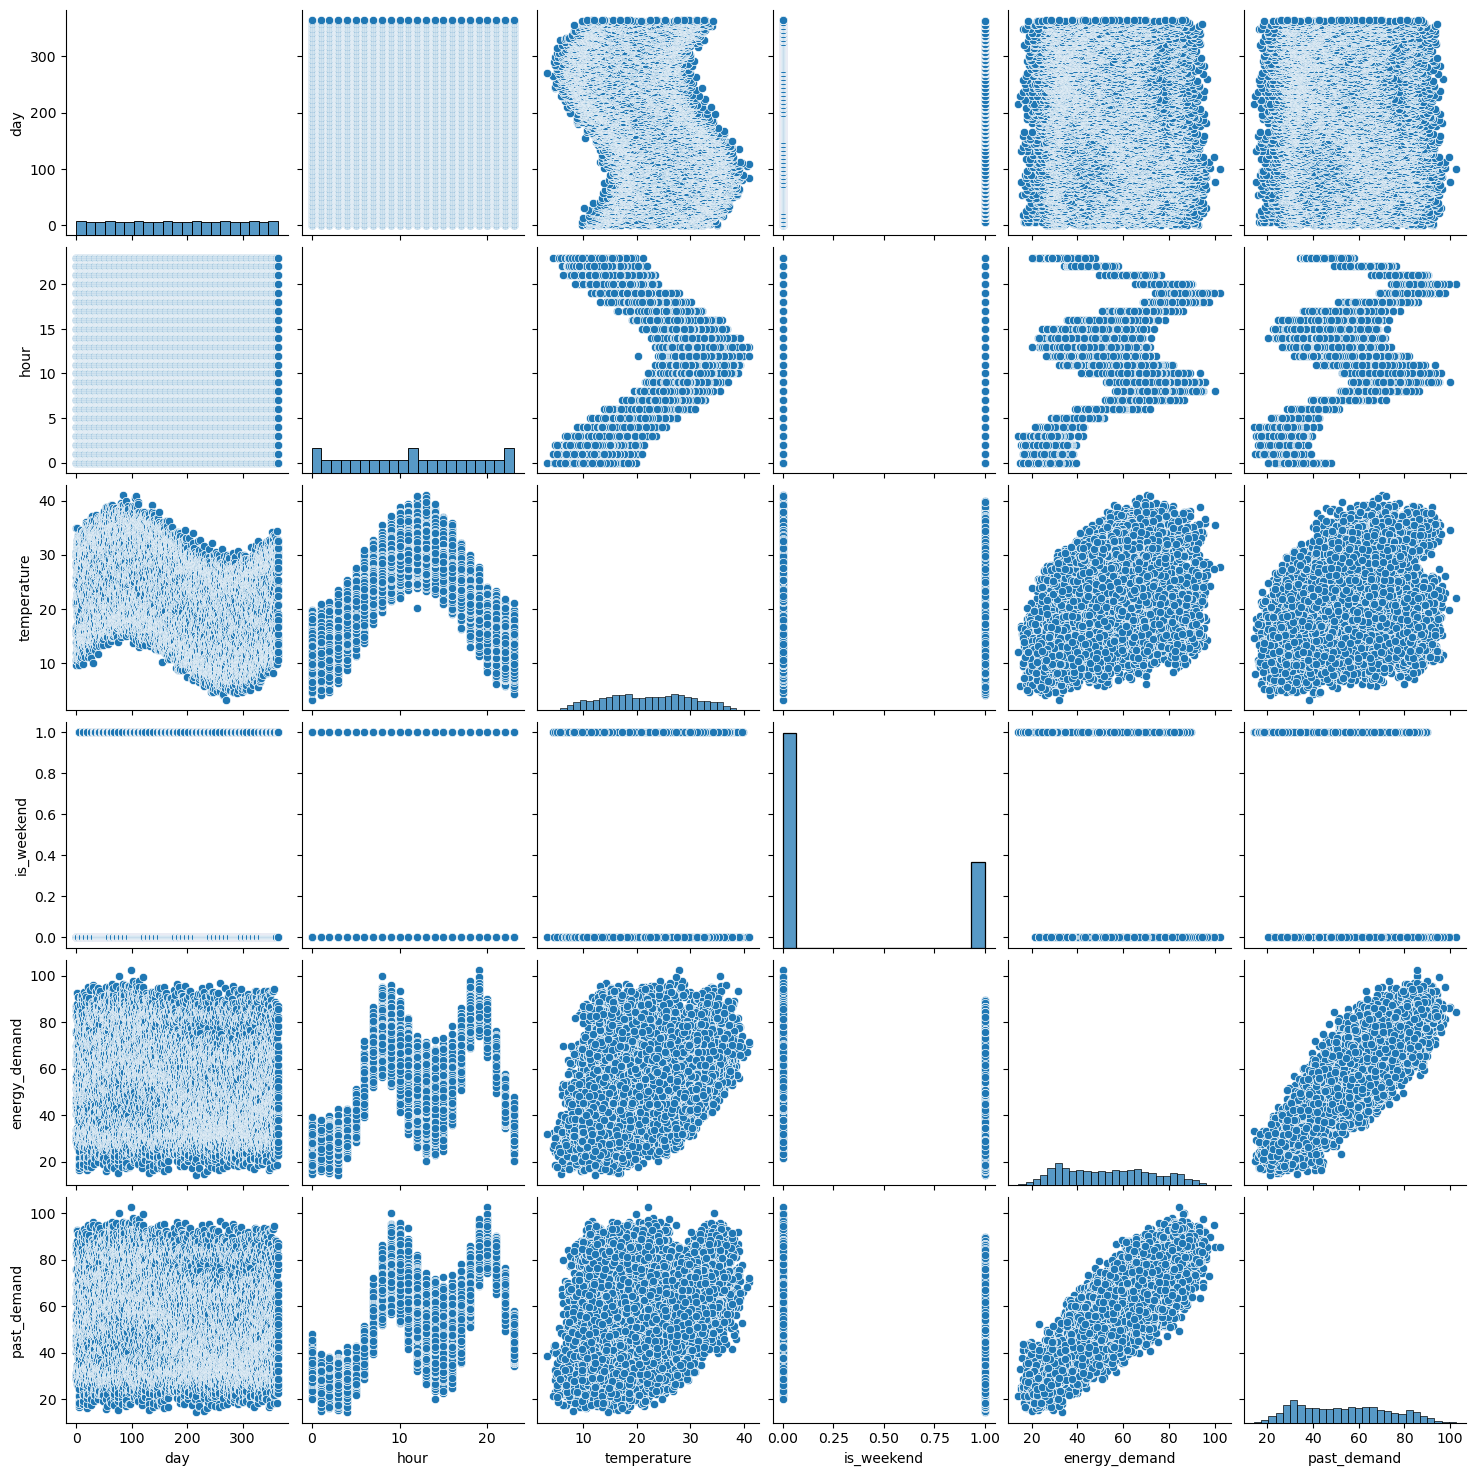

In [6]:
sns.pairplot(df)

In [7]:
df.corr()

,day,hour,temperature,is_weekend,energy_demand,past_demand
day,1.000000e+00,2.567963e-15,-0.339479,1.198190e-02,-0.141364,-0.141361
hour,2.567963e-15,1.000000e+00,0.091307,1.216858e-17,0.482878,0.615537
temperature,-3.394785e-01,9.130699e-02,1.000000,-3.791837e-03,0.414718,0.319125
is_weekend,1.198190e-02,1.216858e-17,-0.003792,1.000000e+00,-0.185512,-0.180018
energy_demand,-1.413639e-01,4.828782e-01,0.414718,-1.855116e-01,1.000000,0.853719
past_demand,-1.413615e-01,6.155375e-01,0.319125,-1.800176e-01,0.853719,1.000000


<Axes: >

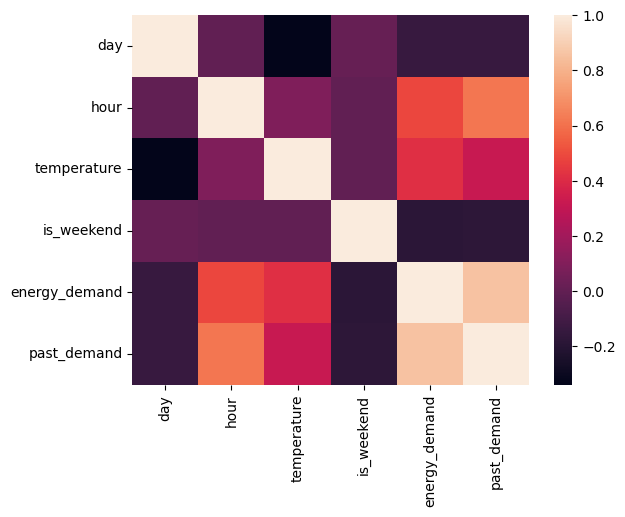

In [8]:
sns.heatmap(df.corr())

In [9]:
df.isnull().sum()

day              0
hour             0
temperature      0
is_weekend       0
energy_demand    0
past_demand      0
dtype: int64

In [10]:
feature_coll= ['hour', 'temperature', 'is_weekend', 'past_demand']
prediction_coll='energy_demand'

In [11]:
X=df[feature_coll].values
y = df[prediction_coll].values

In [12]:
X

array([[ 0.  ,  9.66,  0.  , 28.97],
       [ 1.  , 10.6 ,  0.  , 28.97],
       [ 2.  , 13.95,  0.  , 28.92],
       ...,
       [21.  , 16.78,  0.  , 85.91],
       [22.  , 12.05,  0.  , 69.64],
       [23.  , 13.55,  0.  , 52.24]])

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [15]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=150,       
    max_depth=12,           
    min_samples_split=5,   
    random_state=42,
    n_jobs=-1            
)

In [16]:
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=12, min_samples_split=5, n_estimators=150,
                      n_jobs=-1, random_state=42)

In [17]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
y_pred = rf_model.predict(X_test_scaled)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

In [18]:
mae


2.583490785264605

In [19]:
rmse

np.float64(3.2725986795376865)

In [20]:
r2

0.9723007583488413

In [23]:
def predict_next_24h(model, scaler, is_weekend=0, base_temp=28.0):
    predictions  = []
    temperatures = []
    hours        = list(range(24))
    past_demand = df['energy_demand'].iloc[-1]
    for hour in hours:
        temp = base_temp - 6 + 6 * np.sin((hour - 6) * np.pi / 12)
        temperatures.append(round(temp, 2))
        X_input = np.array([[hour, temp, is_weekend, past_demand]])
        X_scaled = scaler.transform(X_input)
        demand = model.predict(X_scaled)[0]
        predictions.append(round(demand, 2))
        past_demand = demand
    return predictions, hours, temperatures
predicted_demand, hours, temps_24h = predict_next_24h(
    rf_model, scaler, is_weekend=0, base_temp=30.0
)
forecast_df = pd.DataFrame({
    'Hour'              : [f"{h:02d}:00" for h in hours],
    'Temperature (°C)'  : temps_24h,
    'Predicted Demand (kWh)': predicted_demand
})
print(forecast_df.to_string(index=False))

 Hour  Temperature (°C)  Predicted Demand (kWh)
00:00             18.00                   29.66
01:00             18.20                   29.25
02:00             18.80                   30.38
03:00             19.76                   31.50
04:00             21.00                   36.92
05:00             22.45                   43.18
06:00             24.00                   53.29
07:00             25.55                   65.48
08:00             27.00                   73.81
09:00             28.24                   72.32
10:00             29.20                   66.18
11:00             29.80                   56.10
12:00             30.00                   47.24
13:00             29.80                   46.66
14:00             29.20                   43.56
15:00             28.24                   46.16
16:00             27.00                   54.45
17:00             25.55                   68.99
18:00             24.00                   83.29
19:00             22.45                 

 Grid Max Capacity  : 94.78 kWh
  Peak Threshold (80%) : 66.35 kWh
 Peak Hours Detected : [8, 9, 17, 18, 19, 20]
 Total peak hours   : 6 


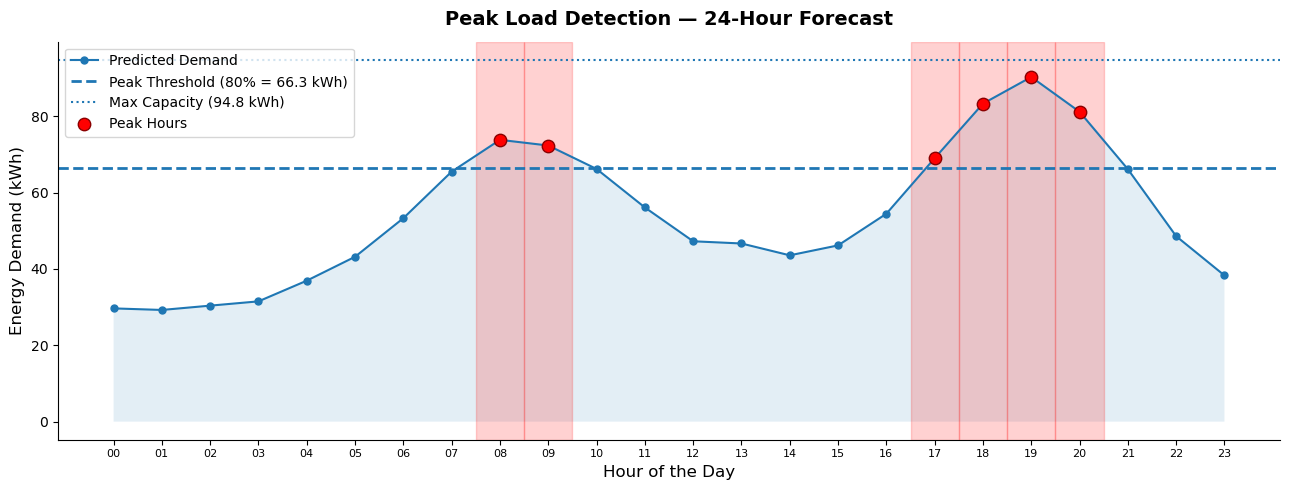

In [34]:
MAX_CAPACITY      = max(predicted_demand) * 1.05  
PEAK_THRESHOLD    = 0.70                        
PEAK_LIMIT        = MAX_CAPACITY * PEAK_THRESHOLD
peak_flags = [demand >= PEAK_LIMIT for demand in predicted_demand]
peak_hours = [h for h, is_peak in zip(hours, peak_flags) if is_peak]
print(f" Grid Max Capacity  : {MAX_CAPACITY:.2f} kWh")
print(f"  Peak Threshold (80%) : {PEAK_LIMIT:.2f} kWh")
print(f" Peak Hours Detected : {peak_hours}")
print(f" Total peak hours   : {len(peak_hours)} ")
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hours, predicted_demand,marker='o', markersize=5, label='Predicted Demand', zorder=3)
ax.fill_between(hours, predicted_demand, alpha=0.12, )
ax.axhline(PEAK_LIMIT, linewidth=2, linestyle='--',label=f'Peak Threshold (80% = {PEAK_LIMIT:.1f} kWh)')
ax.axhline(MAX_CAPACITY, linewidth=1.5, linestyle=':',
           label=f'Max Capacity ({MAX_CAPACITY:.1f} kWh)')
for h in peak_hours:
    ax.axvspan(h - 0.5, h + 0.5, alpha=0.18, color='red', zorder=1)
peak_demands = [predicted_demand[h] for h in peak_hours]
ax.scatter(peak_hours, peak_demands, color='red', s=80, zorder=5,
           label='Peak Hours', edgecolors='darkred', linewidth=1)
ax.set_xlabel('Hour of the Day', fontsize=12)
ax.set_ylabel('Energy Demand (kWh)', fontsize=12)
ax.set_title('Peak Load Detection — 24-Hour Forecast', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(hours)
ax.set_xticklabels([f"{h:02d}" for h in hours], fontsize=8)
ax.legend(fontsize=10, loc='upper left')
fig.patch.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [37]:
def get_suggestions(hour, temperature, demand, peak_limit):

    suggestions = []
    excess_pct  = ((demand - peak_limit) / peak_limit) * 100
    if temperature >= 32:
        suggestions.append(
            f"  AC Temp: It's {temperature:.1f}°C — raise AC setpoint by 2°C to reduce compressor load."
        )
    elif temperature >= 27:
        suggestions.append(
            f" AC Temp: It's {temperature:.1f}°C — raise AC setpoint by 1°C and use fans to supplement."
        )
    if 6 <= hour <= 9:
        suggestions.append(" Washing Machine: Delay laundry to after 10pm (off-peak rates + lower grid stress).")
        suggestions.append("  Dishwasher: Schedule post-dinner wash cycle — not during morning peak.")
    elif 17 <= hour <= 21:
        suggestions.append("  Washing Machine: Consider delaying to after 10pm for off-peak tariff benefit.")
        suggestions.append("  Oven / Microwave: Use microwave instead of oven — up to 80% less energy.")
    if 17 <= hour <= 22:
        suggestions.append("EV Charging: Shift charging to 1am–5am (cheapest, lowest-demand window).")
    elif 7 <= hour <= 9:
        suggestions.append(" EV Charging: Pause or reduce EV charge rate during this morning peak.")
    if hour >= 18 or hour <= 7:
        suggestions.append("  Lighting: Switch to motion-sensor mode or reduce non-essential lighting.")
    if excess_pct > 10:
        suggestions.append(
            f"  High Overload ({excess_pct:.1f}% above threshold): "
            "Consider pausing all non-critical loads for 30–60 minutes."
        )
    elif excess_pct > 5:
        suggestions.append(
            f"Moderate Overload ({excess_pct:.1f}% above threshold): "
            "Stagger usage of heavy appliances — don't run multiple at once."
        )
    else:
        suggestions.append(
            f" Mild Peak ({excess_pct:.1f}% above threshold): "
            "Small adjustments across households can resolve this."
        )

    return suggestions

if not peak_hours:
    print("No peak hours detected  no load shifting required today.")
else:
    print("SMART LOAD SHIFTING SUGGESTIONS")
    print("═" * 60)

    for h in peak_hours:
        demand_h = predicted_demand[h]
        temp_h   = temps_24h[h]
        tips     = get_suggestions(h, temp_h, demand_h, PEAK_LIMIT)

        print(f" Hour {h:02d}:00 — Demand: {demand_h:.1f} kWh  |  Temp: {temp_h:.1f}°C")
        print(f"   (Peak threshold: {PEAK_LIMIT:.1f} kWh | Excess: {demand_h - PEAK_LIMIT:.1f} kWh)")
        print("─" * 55)
        for tip in tips:
            print(f"   {tip}")

    print("\n" + "═" * 60)

SMART LOAD SHIFTING SUGGESTIONS
════════════════════════════════════════════════════════════
 Hour 08:00 — Demand: 73.8 kWh  |  Temp: 27.0°C
   (Peak threshold: 66.3 kWh | Excess: 7.5 kWh)
───────────────────────────────────────────────────────
    AC Temp: It's 27.0°C — raise AC setpoint by 1°C and use fans to supplement.
    Washing Machine: Delay laundry to after 10pm (off-peak rates + lower grid stress).
     Dishwasher: Schedule post-dinner wash cycle — not during morning peak.
    EV Charging: Pause or reduce EV charge rate during this morning peak.
     High Overload (11.2% above threshold): Consider pausing all non-critical loads for 30–60 minutes.
 Hour 09:00 — Demand: 72.3 kWh  |  Temp: 28.2°C
   (Peak threshold: 66.3 kWh | Excess: 6.0 kWh)
───────────────────────────────────────────────────────
    AC Temp: It's 28.2°C — raise AC setpoint by 1°C and use fans to supplement.
    Washing Machine: Delay laundry to after 10pm (off-peak rates + lower grid stress).
     Dishwasher:

In [47]:
def simulate_load_shifting(predicted_demand, peak_flags, compliance_pct, reduction_factor=0.15):
    adjusted  = predicted_demand.copy()
    total_shifted = 0
    night_hours = [h for h in range(24) if 0 <= h <= 5 or 22 <= h <= 23]
    for h in range(24):
        if peak_flags[h]:
            actual_reduction = predicted_demand[h] * reduction_factor * compliance_pct
            adjusted[h]     -= actual_reduction
            total_shifted   += actual_reduction
    if night_hours and total_shifted > 0:
        per_night_hour = total_shifted / len(night_hours)
        for h in night_hours:
            adjusted[h] += per_night_hour
    return adjusted, total_shifted
scenarios = {
    '25% Compliance' : 0.25,
    '50% Compliance' : 0.50,
    '75% Compliance' : 0.75,
}

scenario_results = {}
for label, comp in scenarios.items():
    adj_demand, shifted = simulate_load_shifting(
        predicted_demand, peak_flags, comp, reduction_factor=0.15
    )
    scenario_results[label] = {'demand': adj_demand, 'shifted': shifted}

# Print summary
print("WHAT-IF SIMULATION RESULTS")
print("═" * 50)
print(f"  Baseline total demand    : {sum(predicted_demand):.1f} kWh")
print(f"  Peak hours count         : {sum(peak_flags)} hours")
print()
for label, result in scenario_results.items():
    new_total = sum(result['demand'])
    new_peaks = sum(1 for d in result['demand'] if d >= PEAK_LIMIT)
    print(f"  {label}:")
    print(f"    Demand shifted off-peak : {result['shifted']:.1f} kWh")
    print(f"    Remaining peak hours    : {new_peaks}")
    print()

WHAT-IF SIMULATION RESULTS
══════════════════════════════════════════════════
  Baseline total demand    : 1302.8 kWh
  Peak hours count         : 6 hours

  25% Compliance:
    Demand shifted off-peak : 17.6 kWh
    Remaining peak hours    : 6

  50% Compliance:
    Demand shifted off-peak : 35.2 kWh
    Remaining peak hours    : 5

  75% Compliance:
    Demand shifted off-peak : 52.9 kWh
    Remaining peak hours    : 3



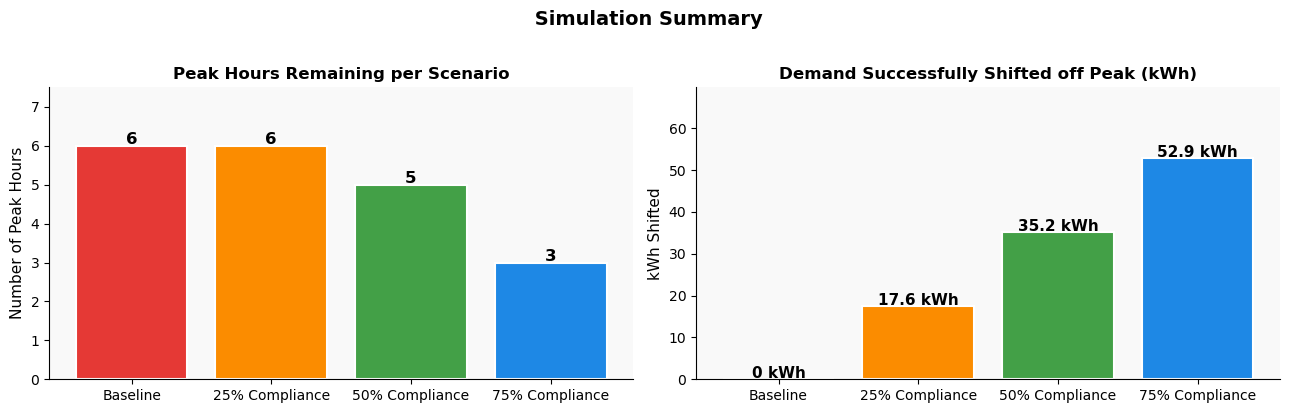


 Smart Energy Demand Optimization System — All steps complete!
────────────────────────────────────────────────────────────
  Model R² Score          : 0.9723
  Peak Threshold          : 66.3 kWh (80% of 94.8 kWh capacity)
  Baseline peak hours     : 6
  Peak hrs at 75% comply  : 3
  Demand shifted (75%)    : 52.9 kWh
────────────────────────────────────────────────────────────


In [42]:

scenario_labels  = ['Baseline'] + list(scenarios.keys())
peak_counts      = [sum(peak_flags)]
demand_reductions = [0]
for label, result in scenario_results.items():
    rem_peaks = sum(1 for d in result['demand'] if d >= PEAK_LIMIT)
    peak_counts.append(rem_peaks)
    demand_reductions.append(round(result['shifted'], 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors_bar = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
bars1 = ax1.bar(scenario_labels, peak_counts, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars1, peak_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(v), ha='center', fontsize=12, fontweight='bold')
ax1.set_title('Peak Hours Remaining per Scenario', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Peak Hours', fontsize=11)
ax1.set_ylim(0, max(peak_counts) + 1.5)
ax1.set_facecolor('#f9f9f9')
ax1.spines[['top', 'right']].set_visible(False)
bars2 = ax2.bar(scenario_labels, demand_reductions, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars2, demand_reductions):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{v} kWh', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Demand Successfully Shifted off Peak (kWh)', fontsize=12, fontweight='bold')
ax2.set_ylabel('kWh Shifted', fontsize=11)
ax2.set_ylim(0, max(demand_reductions) * 1.3 + 1)
ax2.set_facecolor('#f9f9f9')
ax2.spines[['top', 'right']].set_visible(False)

fig.patch.set_facecolor('white')
plt.suptitle(' Simulation Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Smart Energy Demand Optimization System — All steps complete!")
print("─" * 60)
print(f"  Model R² Score          : {r2:.4f}")
print(f"  Peak Threshold          : {PEAK_LIMIT:.1f} kWh (80% of {MAX_CAPACITY:.1f} kWh capacity)")
print(f"  Baseline peak hours     : {sum(peak_flags)}")
print(f"  Peak hrs at 75% comply  : {peak_counts[-1]}")
print(f"  Demand shifted (75%)    : {demand_reductions[-1]} kWh")
print("─" * 60)

In [44]:
import pickle
pickle.dump(rf_model, open("rf_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [46]:

import os
os.getcwd()

'C:\\Users\\hp'

In [49]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")



['rf_model.pkl']